In [2]:
import numpy as np

In [ ]:
class KMeans:
    """
    K-Means est un algorithme de clustering non supervisé qui partitionne les données en K clusters basés sur la proximité des points de données. L'algorithme fonctionne en initialisant K centres de cluster, puis en assignant chaque point de données au cluster le plus proche. Ensuite, les centres de cluster sont recalculés en prenant la moyenne des points assignés à chaque cluster. Ce processus est répété jusqu'à ce que les centres de cluster ne changent plus ou qu'un nombre maximum d'itérations soit atteint.
    """
    def __init__(self, k, calc_metric="euclidean", max_iter=None, init_centr=None, p=2):
        """Initialisation de l'algorithme K-Means avec les paramètres suivants :
        - k : nombre de clusters
        - calc_metric : métrique de distance à utiliser (euclidean, manhattan, cosine, minkowski, hamming, jaccard, mahalanobis)
        - max_iter : nombre maximum d'itérations (None pour convergence)
        - init_centr : méthode d'initialisation des centres de cluster (random, k-means++)
        - p : paramètre pour la métrique Minkowski (par défaut 2 pour la distance euclidienne)
        """
        self.k = k
        self.calc_metric = calc_metric
        self.max_iter = max_iter
        self.init_centr = init_centr
        self.centroids = None
        self.p = p

    def distance(self, x1, x2):
        """Calcule la distance entre deux points x1 et x2 selon la métrique choisie."""
        # X1 et X2 sont les données d'entrée et de test , et la fonction retourne la distance entre elles selon la métrique choisie
        if self.calc_metric == "euclidean":
            return np.linalg.norm(x1 - x2)
        elif self.calc_metric == "cosine":
            denominateur = np.linalg.norm(x1) * np.linalg.norm(x2)
            if denominateur == 0:
                return 0
            return 1 - np.dot(x1, x2) / denominateur
        elif self.calc_metric == "manhattan":
            return np.sum(np.abs(x1 - x2))
        elif self.calc_metric == "minkowski":
            return np.sum(np.abs(x1 - x2) ** self.p) ** (1 / self.p)
        elif self.calc_metric == "hamming":
            return np.sum(x1 != x2) / len(x1)
        elif self.calc_metric == "jaccard":
            intersection = np.sum(np.logical_and(x1, x2))
            union = np.sum(np.logical_or(x1, x2))
            if union == 0:
                return 0
            return 1 - intersection / union
        elif self.calc_metric == "mahalanobis":
            diff = x1 - x2
            return np.sqrt(diff.T @ self.inv_cov_matrix @ diff)
        else:
            raise ValueError(f"Metrique inconnue : {self.calc_metric}.\n Les métriques prises en charge sont : 'euclidean', 'manhattan', 'cosine', 'minkowski', 'hamming', 'jaccard', 'mahalanobis' ")

    def fit(self, x_train):
        """
        Applique l'algorithme K-Means sur les données d'entraînement x_train pour trouver les clusters.
         - x_train : données d'entraînement (array-like)
        """
        self.x_train = np.array(x_train, dtype=float)
        self.clusters = None

        if self.calc_metric == "mahalanobis":
            self.cov_matrix = np.cov(self.x_train, rowvar=False)
            # Vérifier si la matrice est “stable”
            eigvals = np.linalg.eigvals(self.cov_matrix)
            if np.min(eigvals) > 1e-10:
                # inverse normal
                self.inv_cov_matrix = np.linalg.inv(self.cov_matrix)
            else:
                # régularisation
                self.inv_cov_matrix = np.linalg.inv(self.cov_matrix + 1e-5 * np.eye(self.cov_matrix.shape[0]))
        
        if self.init_centr == "random":
            np.random.seed(42)  # pour la reproductibilité

            indices = np.random.choice(self.x_train.shape[0], self.k, replace=False)
            self.centroids = self.x_train[indices]

        elif self.init_centr == "k-means++":
            np.random.seed(42)  # pour la reproductibilité

            # Choisir le premier centre de manière aléatoire
            self.centroids = np.empty((self.k, self.x_train.shape[1]))

            first_index = np.random.choice(self.x_train.shape[0])
            self.centroids[0] = self.x_train[first_index]

            for i in range(1, self.k):
                distances = np.array([min(self.distance(x, c) ** 2 for c in self.centroids[:i]) for x in self.x_train])
                probabilities = distances / np.sum(distances)
                next_index = np.random.choice(self.x_train.shape[0], p=probabilities)
                self.centroids[i] = self.x_train[next_index]

        else :
            raise ValueError(f"Methode d\'nitialisation des centroides inconnue : {self.init_centr}.\n Les méthodes d'initialisation prises en charge sont : 'random', 'k-means++' ")

        if self.max_iter is None:

            while True:
                # Assignation des points aux clusters
                self.clusters = [[] for _ in range(self.k)]
                self.labels = []
                
                for x in self.x_train:
                    distances = [self.distance(x, c) for c in self.centroids]
                    closest_centroid = np.argmin(distances)
                    self.labels.append(closest_centroid)
                    self.clusters[closest_centroid].append(x)

                # Recalcul des centres de cluster
                new_centroids = np.array([np.mean(cluster, axis=0) if cluster else self.centroids[i] for i, cluster in enumerate(self.clusters)])
                
                # Vérification de la convergence
                if np.allclose(self.centroids, new_centroids):
                    self.centroids = new_centroids
                    break
                self.centroids = new_centroids
        else:
            for _ in range(self.max_iter):
                # Assignation des points aux clusters
                self.clusters = [[] for _ in range(self.k)]
                self.labels = []
                for x in self.x_train:
                    distances = [self.distance(x, c) for c in self.centroids]
                    closest_centroid = np.argmin(distances)
                    self.labels.append(closest_centroid)
                    self.clusters[closest_centroid].append(x)

                # Recalcul des centres de cluster
                new_centroids = np.array([np.mean(cluster, axis=0) if cluster else self.centroids[i] for i, cluster in enumerate(self.clusters)])

                # Vérification de la convergence
                if np.allclose(self.centroids, new_centroids):
                    break

                self.centroids = new_centroids
        
        return self.clusters
        
    def silhouette_score(self,index=None):
        """Calcule le score de silhouette pour les données d'entraînement. Si index est fourni, calcule le score de silhouette pour le point de données à cet index."""
        D = np.linalg.norm(
            self.x_train[:, np.newaxis] - self.x_train,
            axis=2
        )
        # Amelioration possible : Faire en sorte que la matrice D prenne en compte le metrique choisie (euclidean, manhattan, cosine, minkowski, hamming, jaccard, mahalanobis) au lieu de la distance euclidienne par défaut.
        a = np.array(self.a(D))
        b = np.array(self.b(D))

        if index is not None:
            a_idx = a[index]
            b_idx = b[index]
            if max(a_idx, b_idx) == 0:
                return 0
            return (b_idx - a_idx) / max(a_idx, b_idx)
        else:
            denom = np.maximum(a, b)
            result = np.zeros_like(denom)
            mask = denom != 0
            result[mask] = (b[mask] - a[mask]) / denom[mask]
            return np.mean(result)

    def a(self,D):
        """
        Calcule la distance moyenne intra-cluster pour chaque point de données d'entraînement.
        Retourne une liste de distances moyennes intra-cluster pour chaque point de données."""
        # mean_intra_cluster = []
        # for i,x in enumerate(self.x_train):
        #     mean_intra_cluster.append(np.mean([self.distance(x, c) for c in self.clusters[self.labels[i]]]))
        # return mean_intra_cluster

        a = np.zeros(len(self.x_train))

        for i in range(self.k):
            mask = self.labels == i
            cluster_points = D[mask][:, mask]

            if cluster_points.shape[0] > 1:
                a[mask] = (np.sum(cluster_points, axis=1) / (cluster_points.shape[1] - 1))
            else:
                a[mask] = 0
        return a

    
    def b(self,D):
        """Calcule la distance moyenne inter-cluster pour chaque point de données d'entraînement.
        Retourne une liste de distances moyennes inter-cluster pour chaque point de données."""
        # mean_inter_cluster = []
        # for i,x in enumerate(self.x_train):
        #     mean_inter_cluster.append(np.min([np.mean([self.distance(x, c) for c in self.clusters[j]]) for j in range(self.k) if j != self.labels[i]]))
        # return mean_inter_cluster

        b = np.full(len(self.x_train), np.inf)

        for i in range(self.k):
            mask_i = self.labels == i

            for j in range(self.k):
                if i == j:
                    continue

                mask_j = self.labels == j

                dist = D[mask_i][:, mask_j].mean(axis=1)
                b[mask_i] = np.minimum(b[mask_i], dist)
        return b

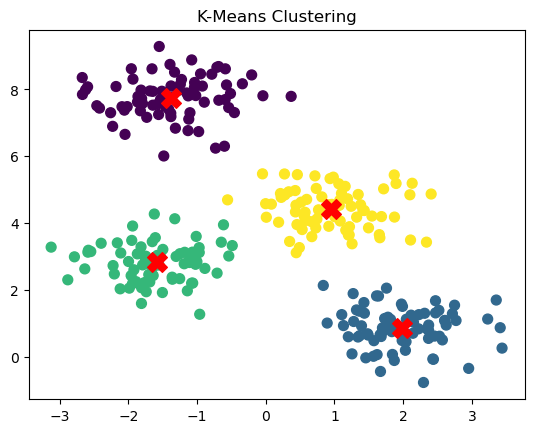

In [9]:
# Exemple d'utilisation
if __name__ == "__main__":
    # Générer des données d'exemple
    from sklearn.datasets import make_blobs
    import matplotlib.pyplot as plt

    X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

    # Appliquer K-Means
    kmeans = KMeans(k=4, calc_metric="euclidean", max_iter=100, init_centr="k-means++")
    clusters = kmeans.fit(X)

    # Afficher les clusters et les centres
    plt.scatter(X[:, 0], X[:, 1], s=50, c=kmeans.labels, cmap='viridis')
    plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], s=200, c='red', marker='X')
    plt.title("K-Means Clustering")
    plt.show()

# caché

In [ ]:
"""
K-Means est un algorithme de clustering non supervisé qui partitionne les données en K clusters basés sur la proximité des points de données. L'algorithme fonctionne en initialisant K centres de cluster, puis en assignant chaque point de données au cluster le plus proche. Ensuite, les centres de cluster sont recalculés en prenant la moyenne des points assignés à chaque cluster. Ce processus est répété jusqu'à ce que les centres de cluster ne changent plus ou qu'un nombre maximum d'itérations soit atteint.
"""
class KMeans:
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        
    def fit(self, X):
        n_samples, n_features = X.shape
        # Initialisation aléatoire des centres de cluster
        np.random.seed(42)
        random_indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[random_indices]
        
        for _ in range(self.max_iter):
            # Assignation des points de données aux clusters les plus proches
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            closest_centroids = np.argmin(distances, axis=1)
            
            # Recalcul des centres de cluster
            new_centroids = np.array([X[closest_centroids == i].mean(axis=0) for i in range(self.n_clusters)])
            
            # Vérification de la convergence
            if np.linalg.norm(new_centroids - self.centroids) < self.tol:
                break
            
            self.centroids = new_centroids
            
    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)